In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import json
import os

from Encoder import*
from Tools.model_tools import load_configs
from Tools.data_utils import extract_params_from_filename
from Tools.analysis_tools import*

In [2]:
# Percorso del database
decoder_database_path = "decoderDatabase.json"

# Carica tutte le configurazioni disponibili
all_decoder = load_configs(decoder_database_path)

# Visualizza le configurazioni disponibili
for model_name, config in all_decoder.items():
    print(model_name, config)

1 {'decoder_layers': [5, 10, 20, 30, 40], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20_noise6,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.0001, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 1e-06}}, 'Encoder': '3'}
1.pth {'decoder_layers': [5, 10, 20, 30, 40], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20_noise6,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.0001, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 1e-06}}, 'Encoder': '3'}
1.pth.pth {'decoder_layers': [5, 10, 20, 30, 40], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20_noise6,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.0001, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience'

In [3]:
# Scegli un modello specifico
decoder_name = "1"  # Cambia con il nome desiderato
decoder_config = all_decoder.get(decoder_name)

if decoder_config is None:
    raise ValueError(f"Il modello {decoder_name} non esiste nel database.")

print(f"Il decoder è stato allenato con il modello Encoder : {decoder_config["Encoder"]}" )

Il decoder è stato allenato con il modello Encoder : 3


In [11]:
# Percorso al file del decoder salvato
decoder_file_path = os.path.join("Decoder Models", f"{decoder_name}.pth")
decoder, decoder_checkpoint = load_decoder(decoder_file_path, Decoder)

decoder_epoch = decoder_checkpoint['epoch']
decoder_stopped_epoch = decoder_checkpoint['stopped_epoch']
decoder_train_losses = decoder_checkpoint['train_losses']
decoder_val_losses = decoder_checkpoint['val_losses']
decoder_gradient_history = decoder_checkpoint['gradient_history']

Decoder and training info loaded from Decoder Models/1.pth


In [12]:
#Scelta dell'Encoder da concatenare al Decoder selezionato:
encoder_database_path = "encoderDatabase.json"
all_encoders = load_configs(encoder_database_path)

for model_name, config in all_encoders.items():
    print(model_name, config)

encoder_name = decoder_config["Encoder"] # Cambia per cambiare l'encoder concatenato

encoder_config = all_encoders.get(encoder_name)
if encoder_config is None:
    raise ValueError(f"Il modello {decoder_config["Encoder"]} non esiste nel database.")

if encoder_config["latent_dim"] != decoder_config["latent_dim"]:
    raise ValueError("Le dimensioni latenti dell'encoder e del decoder non coincidono.")


#Caricamento del modello preallenato dell'encoder
encoder_model_path = "Encoder Models"
encoder_path = os.path.join(encoder_model_path, encoder_name + ".pth")

encoder, encoder_checkpoint = load_encoder(encoder_path, Encoder)

encoder_epoch = encoder_checkpoint['epoch']
encoder_stopped_epoch = encoder_checkpoint['stopped_epoch']
encoder_train_losses = encoder_checkpoint['train_losses']
encoder_val_losses = encoder_checkpoint['val_losses']
recon_losses = encoder_checkpoint['recon_losses']
kld_losses = encoder_checkpoint['kld_losses']
effective_kld_losses = encoder_checkpoint['effective_kld_losses']
beta_values = encoder_checkpoint['beta_values']
encoder_gradient_history = encoder_checkpoint['gradient_history']

1 {'layer_dims': [20, 17, 15, 12, 10, 8, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.05, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20_noise3,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}
2 {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.05, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20_noise3,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}
3 {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.05, 'kl_annealing_epochs': 700, 'd

/workspaces/Lorenz-Toy/Tools/training_tools.py:348: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


In [9]:
batch_size = decoder_config["batch_size"]

train_data = decoder_checkpoint["train_data"]
val_data = decoder_checkpoint["val_data"]

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

total_sample = len(train_data)+len(val_data)
print(f"Numero totale di campioni: {total_sample}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

Numero totale di campioni: 9715
Numero di campioni di training: 5829
Numero di campioni di validazione: 3886


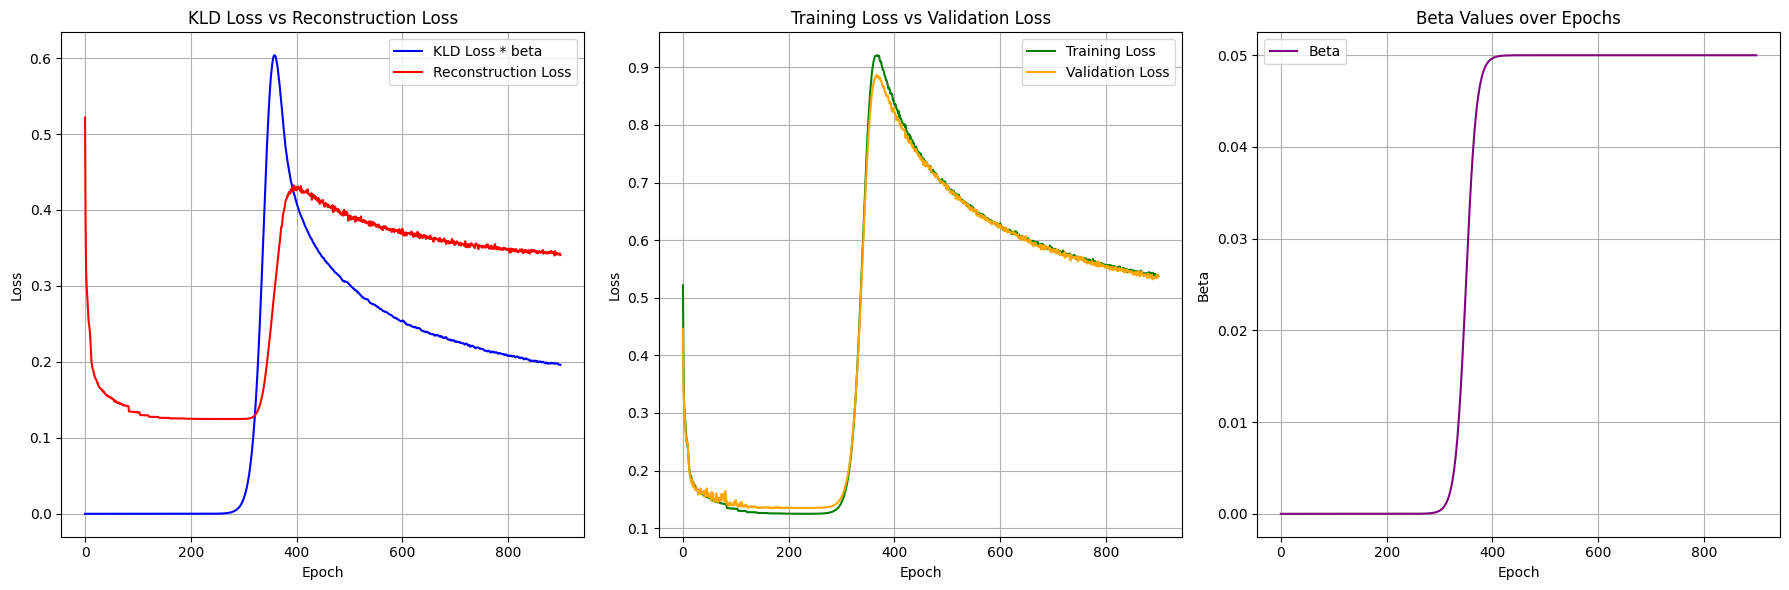

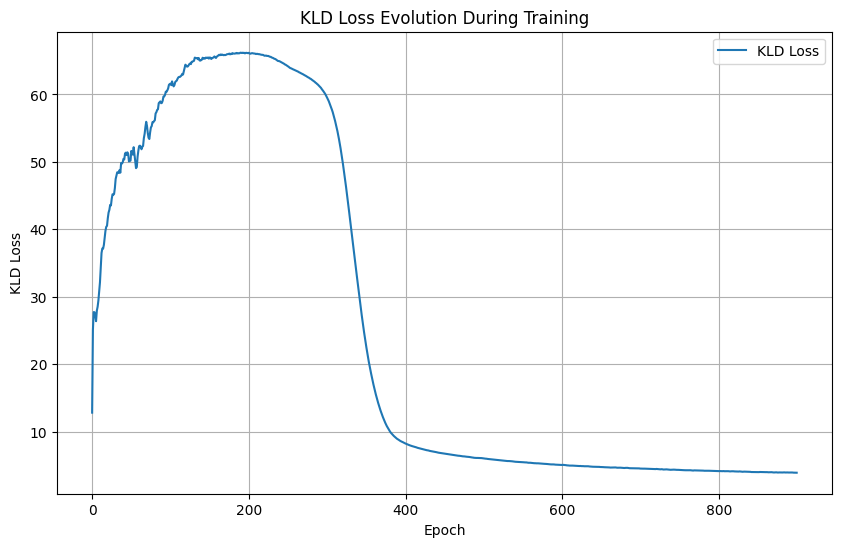

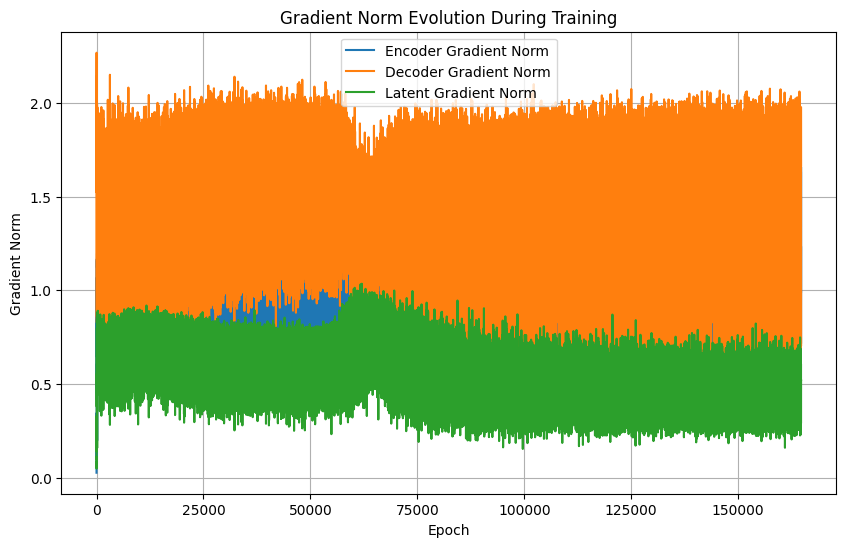

In [14]:
plot_results(encoder_train_losses, encoder_val_losses, recon_losses, kld_losses,effective_kld_losses, beta_values, encoder_gradient_history)

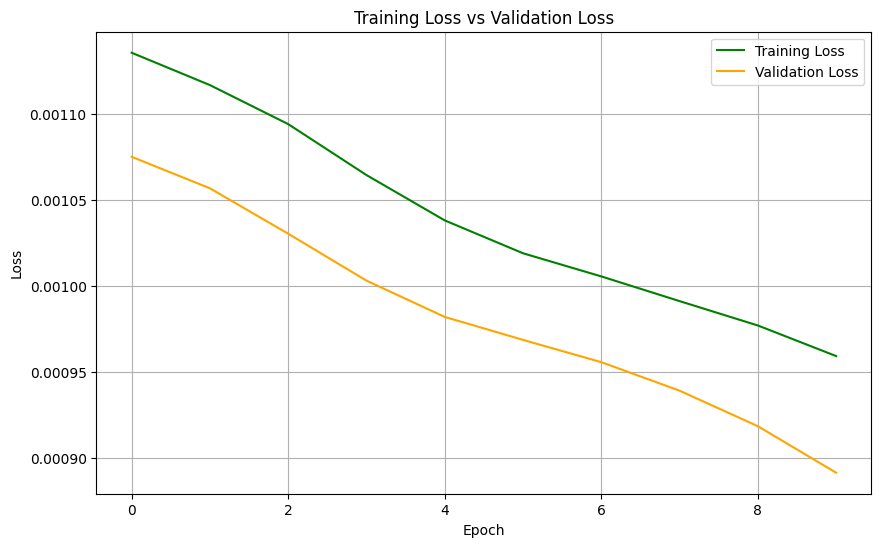

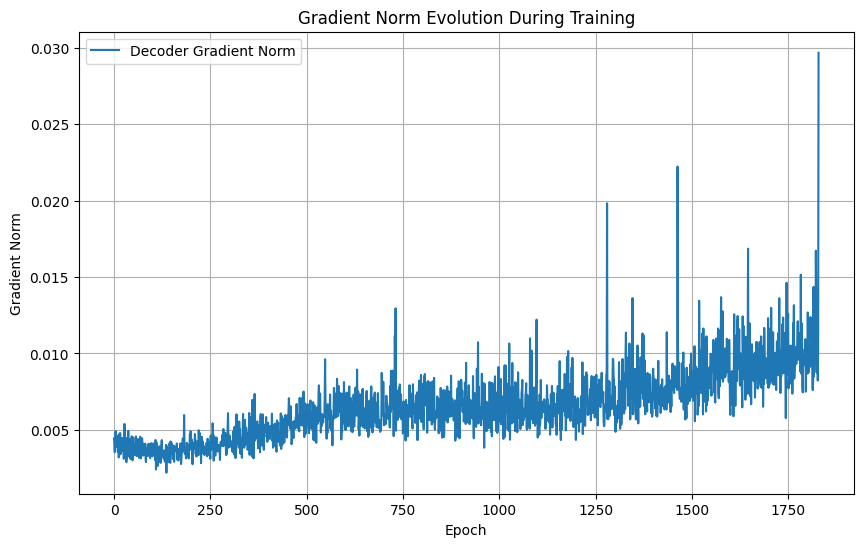

In [15]:
plot_Decoder_results(decoder_train_losses, decoder_val_losses, decoder_gradient_history)